# Shuffled-Control Analysis

Compares the shuffled-control experiment (weights shuffled within cell-type pairs, destroying synapse identity) against the varying-noise results. The shuffled control tests whether learned scaling factors exploit specific connectome structure or just compensate for block-level statistics.

In [ ]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from utils.reproducibility import load_experiment_config
from analysis.inference import run_feedforward_inference
from analysis import fluctuation_r_squared, firing_rates_from_spikes, r_squared
from visualization import use_project_style, plot_r2_comparison_bar

use_project_style()

In [ ]:
# Paths
shuffled_config = load_experiment_config("experiment.toml")
varying_noise_config = load_experiment_config("../varying-noise/experiment.toml")
teacher_config = load_experiment_config(
    "../../generate-teacher-activity/experiment.toml"
)

TEACHER_DATA = teacher_config["output_dir"] / "results"
VARYING_NOISE_DIR = varying_noise_config["output_dir"]
SHUFFLED_CONTROL_DIR = shuffled_config["output_dir"]

# Inference parameters
N_INFERENCE_CHUNKS = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Data availability flags
HAS_VARYING_NOISE = VARYING_NOISE_DIR.exists()
HAS_SHUFFLED = SHUFFLED_CONTROL_DIR.exists()

print(f"Device: {DEVICE}")
print(f"Varying-noise data: {'found' if HAS_VARYING_NOISE else 'NOT FOUND'}")
print(f"Shuffled-control data: {'found' if HAS_SHUFFLED else 'NOT FOUND'}")

### Helper Functions

In [ ]:
def compute_fr_r2(plot_data_path):
    """Compute firing-rate R² from a plot_data.npz file."""
    td = np.load(plot_data_path)
    dt_val = float(td["dt"])
    teacher_fr = firing_rates_from_spikes(td["teacher_spikes"], dt_val)
    student_fr = firing_rates_from_spikes(td["student_spikes"], dt_val)
    return r_squared(teacher_fr, student_fr)


def compute_fluct_r2(plot_data_path, tau_ms=50.0):
    """Compute spike-train fluctuation R² from a plot_data.npz file."""
    td = np.load(plot_data_path)
    dt_val = float(td["dt"])
    return fluctuation_r_squared(
        td["teacher_spikes"].astype(np.float32),
        td["student_spikes"].astype(np.float32),
        tau_ms,
        dt_val,
    )


def run_inference_with_target_sf(run_dir, params_path):
    """Run inference with target SFs and return (student_spikes, teacher_spikes, dt)."""
    cache_path = run_dir / "target_sf_plot_data.npz"

    target_sf = np.load(run_dir / "targets" / "target_scaling_factors.npz")[
        "feedforward_scaling_factors"
    ]

    result = run_feedforward_inference(
        params_file=params_path,
        run_dir=run_dir,
        scaling_factors_FF=target_sf,
        n_analysis_chunks=N_INFERENCE_CHUNKS,
        cache_path=cache_path,
        device=DEVICE,
        desc=f"target-SF {run_dir.name}",
    )

    return result["student_spikes"], result["teacher_spikes"], float(result["dt"])

### Load Data

In [ ]:
# Load varying-noise results
if HAS_VARYING_NOISE:
    run_dirs = sorted(
        [
            d
            for d in VARYING_NOISE_DIR.iterdir()
            if d.is_dir() and d.name.startswith("noise-")
        ]
    )
    print(f"Found {len(run_dirs)} varying-noise runs")

    results = []
    for run_dir in run_dirs:
        match = re.search(r"noise-([\d.]+)", run_dir.name)
        if not match:
            continue
        noise_frac = float(match.group(1))

        metrics_path = run_dir / "training_metrics.csv"
        if not metrics_path.exists():
            continue

        df = pd.read_csv(metrics_path)
        final = df.iloc[-1]

        results.append(
            {
                "noise_fraction": noise_frac,
                "final_loss": final["total_loss"],
                "student_fr_exc": final["firing_rate/student_excitatory_mean"],
                "student_fr_inh": final["firing_rate/student_inhibitory_mean"],
                "teacher_fr_exc": final["firing_rate/teacher_excitatory_mean"],
                "teacher_fr_inh": final["firing_rate/teacher_inhibitory_mean"],
                "exc_to_exc": final["scaling_factors/excitatory_to_excitatory_value"],
                "exc_to_inh": final["scaling_factors/excitatory_to_inhibitory_value"],
                "inh_to_exc": final["scaling_factors/inhibitory_to_excitatory_value"],
                "inh_to_inh": final["scaling_factors/inhibitory_to_inhibitory_value"],
                "mitral_to_exc": final["scaling_factors/mitral_to_excitatory_value"],
                "mitral_to_inh": final["scaling_factors/mitral_to_inhibitory_value"],
            }
        )

    results_df = (
        pd.DataFrame(results).sort_values("noise_fraction").reset_index(drop=True)
    )
    print(f"Noise levels: {results_df['noise_fraction'].tolist()}")
else:
    print("SKIPPED: varying-noise data not found")

# Load shuffled-control results
if HAS_SHUFFLED:
    shuffled_metrics_path = SHUFFLED_CONTROL_DIR / "training_metrics.csv"
    if shuffled_metrics_path.exists():
        shuffled_df = pd.read_csv(shuffled_metrics_path)
        shuffled_final = shuffled_df.iloc[-1]
        print(f"Shuffled control: {len(shuffled_df)} logged steps")
    else:
        HAS_SHUFFLED = False
        print("SKIPPED: shuffled-control training_metrics.csv not found")
else:
    print("SKIPPED: shuffled-control data not found")

### 1. Weight Scatter: Original vs Shuffled

Shows that shuffling destroys synapse identity (low correlation) while preserving block-level statistics.

In [ ]:
if not HAS_SHUFFLED:
    print("SKIPPED: no shuffled-control data")
else:
    teacher_data = np.load(TEACHER_DATA / "network_structure.npz")
    teacher_ff_weights = teacher_data["feedforward_weights"]
    teacher_rec_weights = teacher_data["recurrent_weights"]
    teacher_ff_connectivity = teacher_data["feedforward_connectivity"]
    teacher_rec_connectivity = teacher_data["recurrent_connectivity"]
    teacher_cell_type_indices = teacher_data["cell_type_indices"]
    teacher_ff_cell_type_indices = teacher_data["feedforward_cell_type_indices"]

    # Load shuffled initial state
    shuffled_state = np.load(
        SHUFFLED_CONTROL_DIR / "initial_state" / "network_structure.npz"
    )
    perturbed_weights = shuffled_state["feedforward_weights"]
    shuffled_cell_type_indices = shuffled_state["feedforward_cell_type_indices"]

    # Undo SF perturbation to get the pure shuffled weights
    target_sf = np.load(
        SHUFFLED_CONTROL_DIR / "targets" / "target_scaling_factors.npz"
    )["feedforward_scaling_factors"]

    shuffled_weights = perturbed_weights.copy()
    sf_matrix = target_sf[
        shuffled_cell_type_indices[:, None],
        teacher_cell_type_indices[None, :],
    ]
    shuffled_weights *= sf_matrix

    # Concatenate original teacher weights
    original_concatenated = np.concatenate(
        [teacher_ff_weights, teacher_rec_weights], axis=0
    )
    original_connectivity = np.concatenate(
        [teacher_ff_connectivity, teacher_rec_connectivity], axis=0
    )
    connected_mask = original_connectivity > 0

    original_connected = original_concatenated[connected_mask]
    shuffled_connected = shuffled_weights[connected_mask]

    # Distance-weighted sampling so tails are represented
    max_points = 2000
    rng_plot = np.random.default_rng(42)
    dist = np.sqrt(original_connected**2 + shuffled_connected**2)
    prob = dist / dist.sum()
    idx = rng_plot.choice(len(original_connected), max_points, replace=False, p=prob)

    corr = np.corrcoef(original_connected, shuffled_connected)[0, 1]

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(
        original_connected[idx],
        shuffled_connected[idx],
        alpha=0.6,
        s=1,
    )

    lims = [
        min(0, shuffled_connected.min()),
        np.percentile(np.concatenate([original_connected, shuffled_connected]), 95),
    ]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    stats_text = (
        f"Original: \u03bc={original_connected.mean():.6f}, \u03c3={original_connected.std():.6f}\n"
        f"Shuffled: \u03bc={shuffled_connected.mean():.6f}, \u03c3={shuffled_connected.std():.6f}\n"
        f"Corr: r={corr:.4f}"
    )
    ax.text(
        0.05,
        0.95,
        stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        fontfamily="monospace",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    ax.set_xlabel("Original Weight")
    ax.set_ylabel("Shuffled Weight")
    ax.set_title("Original vs Shuffled Weights")
    ax.set_aspect("equal")

    plt.tight_layout()
    fig.savefig(SHUFFLED_CONTROL_DIR / "weight_scatter.svg", bbox_inches="tight")
    plt.show()
    print(f"Saved to {SHUFFLED_CONTROL_DIR / 'weight_scatter.svg'}")

### 2. Loss Comparison

Varying-noise loss curve with the shuffled-control final loss overlaid as a horizontal line.

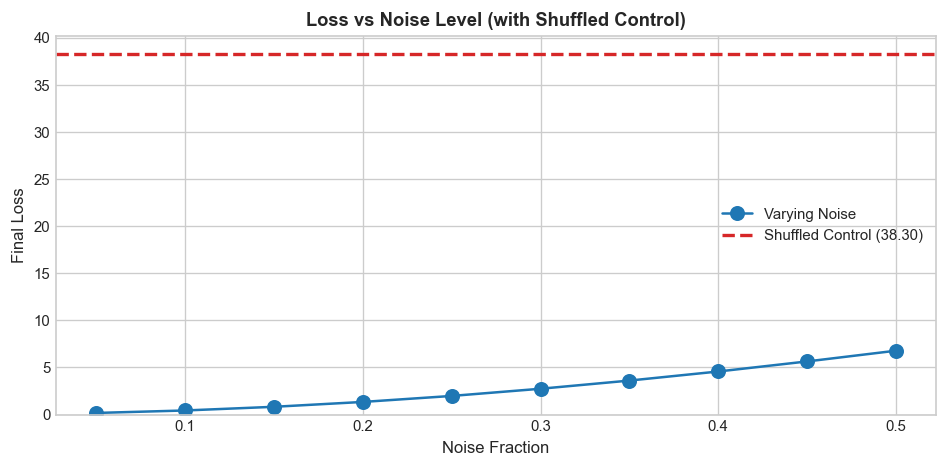

In [49]:
if not (HAS_VARYING_NOISE and HAS_SHUFFLED):
    print("SKIPPED: need both varying-noise and shuffled-control data")
else:
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(
        results_df["noise_fraction"],
        results_df["final_loss"],
        "o-",
        color="C0",
        markersize=8,
        label="Varying Noise",
    )

    shuffled_loss = shuffled_final["total_loss"]
    ax.axhline(
        y=shuffled_loss,
        color="C3",
        linestyle="--",
        linewidth=2,
        label=f"Shuffled Control ({shuffled_loss:.2f})",
    )

    ax.set_xlabel("Noise Fraction")
    ax.set_ylabel("Final Loss")
    ax.set_title("Loss vs Noise Level (with Shuffled Control)", fontweight="bold")
    ax.set_ylim(0, None)
    ax.legend(loc="best")

    plt.tight_layout()
    plt.show()

### 3. Scaling Factors Comparison

Final learned scaling factors for varying-noise vs shuffled-control.

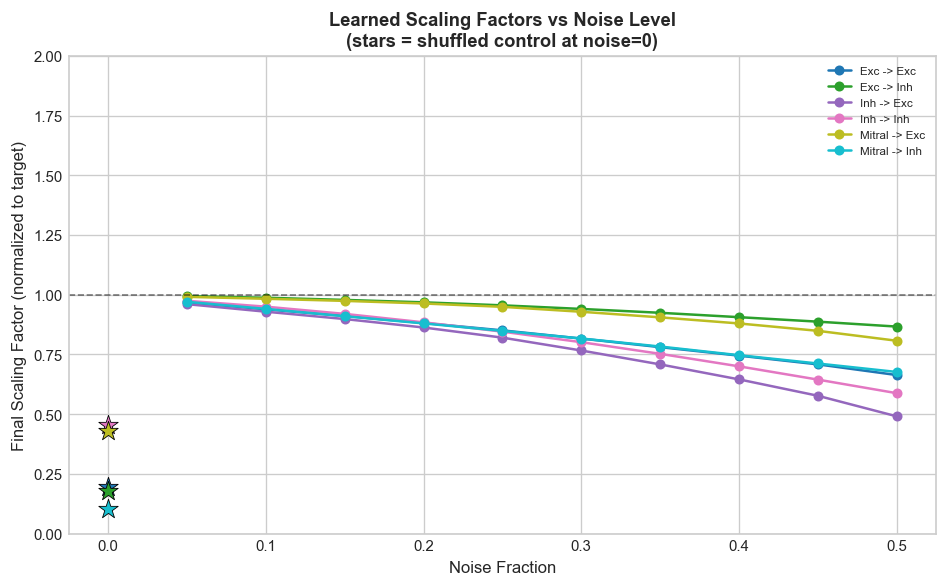

In [50]:
if not (HAS_VARYING_NOISE and HAS_SHUFFLED):
    print("SKIPPED: need both varying-noise and shuffled-control data")
else:
    sf_cols = [
        ("exc_to_exc", "Exc -> Exc"),
        ("exc_to_inh", "Exc -> Inh"),
        ("inh_to_exc", "Inh -> Exc"),
        ("inh_to_inh", "Inh -> Inh"),
        ("mitral_to_exc", "Mitral -> Exc"),
        ("mitral_to_inh", "Mitral -> Inh"),
    ]

    sf_col_map = {
        "exc_to_exc": "scaling_factors/excitatory_to_excitatory_value",
        "exc_to_inh": "scaling_factors/excitatory_to_inhibitory_value",
        "inh_to_exc": "scaling_factors/inhibitory_to_excitatory_value",
        "inh_to_inh": "scaling_factors/inhibitory_to_inhibitory_value",
        "mitral_to_exc": "scaling_factors/mitral_to_excitatory_value",
        "mitral_to_inh": "scaling_factors/mitral_to_inhibitory_value",
    }

    fig, ax = plt.subplots(figsize=(8, 5))

    colors = plt.cm.tab10(np.linspace(0, 1, len(sf_cols)))

    for (col, label), color in zip(sf_cols, colors):
        # Varying noise trajectory
        ax.plot(
            results_df["noise_fraction"],
            results_df[col],
            "o-",
            markersize=5,
            color=color,
            label=label,
        )

        # Shuffled control point (plotted at x=0 since no noise)
        shuffled_val = shuffled_final[sf_col_map[col]]
        ax.scatter(
            [0.0],
            [shuffled_val],
            marker="*",
            s=150,
            color=color,
            edgecolors="black",
            linewidths=0.5,
            zorder=5,
        )

    ax.axhline(y=1.0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax.set_xlabel("Noise Fraction")
    ax.set_ylabel("Final Scaling Factor (normalized to target)")
    ax.set_title(
        "Learned Scaling Factors vs Noise Level\n(stars = shuffled control at noise=0)",
        fontweight="bold",
    )
    ax.set_ylim(0, 2)
    ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

### 4. R² Comparison: Noise 0.40 vs Shuffled Control

Bar chart comparing firing rate R² and spike train fluctuation R² between the noise=0.40 condition and the shuffled control.

In [ ]:
noise_040_path = VARYING_NOISE_DIR / "noise-0.40" / "final_state" / "plot_data.npz"
shuffled_path = SHUFFLED_CONTROL_DIR / "final_state" / "plot_data.npz"

r2_values = {}
for label, path in [("Noise 0.40", noise_040_path), ("Shuffled", shuffled_path)]:
    if not path.exists():
        print(f"SKIPPED: {path} not found")
        continue
    r2_values[label] = {
        "Firing Rate": compute_fr_r2(path),
        "Fluctuation": compute_fluct_r2(path),
    }
    print(
        f"{label}: FR R\u00b2={r2_values[label]['Firing Rate']:.4f}, Fluct R\u00b2={r2_values[label]['Fluctuation']:.4f}"
    )

In [ ]:
if len(r2_values) == 2:
    conditions = ["Noise 0.40", "Shuffled"]
    colors = ["C0", "C3"]

    fig = plot_r2_comparison_bar(
        conditions,
        {
            "Firing Rate R\u00b2": [r2_values[c]["Firing Rate"] for c in conditions],
            "Fluctuation R\u00b2": [r2_values[c]["Fluctuation"] for c in conditions],
        },
        condition_colors=colors,
        ylim=(-1, 1.05),
        title="R\u00b2 Comparison: Learned Scaling Factors",
    )
    fig.savefig(SHUFFLED_CONTROL_DIR / "r2_comparison.svg", bbox_inches="tight")
    plt.show()
    print(f"Saved to {SHUFFLED_CONTROL_DIR / 'r2_comparison.svg'}")
else:
    print("SKIPPED: need both noise-0.40 and shuffled-control data")

### 5. R² with Target Scaling Factors ("Correct Student")

Same comparison, but running inference with the *target* scaling factors instead of the learned ones. This is the theoretical best that the scaling factor approach can achieve — it tells us whether the gap above is due to imperfect learning or a fundamental limit of the shuffled weights.

In [ ]:
noise_040_params = varying_noise_config["parameters_file"]
shuffled_params = shuffled_config["parameters_file"]
noise_040_dir = VARYING_NOISE_DIR / "noise-0.40"

r2_target_sf = {}

for label, run_dir, params_path in [
    ("Noise 0.40", noise_040_dir, noise_040_params),
    ("Shuffled", SHUFFLED_CONTROL_DIR, shuffled_params),
]:
    if not run_dir.exists():
        print(f"SKIPPED: {run_dir} not found")
        continue
    print(f"{label}:")
    student_sp, teacher_sp, dt_val = run_inference_with_target_sf(run_dir, params_path)

    teacher_fr = firing_rates_from_spikes(teacher_sp, dt_val)
    student_fr = firing_rates_from_spikes(student_sp, dt_val)
    fr_r2 = r_squared(teacher_fr, student_fr)

    fluct_r2 = fluctuation_r_squared(
        teacher_sp.astype(np.float32),
        student_sp.astype(np.float32),
        50.0,
        dt_val,
    )

    r2_target_sf[label] = {"Firing Rate": fr_r2, "Fluctuation": fluct_r2}
    print(f"  FR R\u00b2={fr_r2:.4f}, Fluct R\u00b2={fluct_r2:.4f}")

In [ ]:
if len(r2_target_sf) == 2:
    conditions = ["Noise 0.40", "Shuffled"]
    colors = ["C0", "C3"]

    fig = plot_r2_comparison_bar(
        conditions,
        {
            "Firing Rate R\u00b2": [r2_target_sf[c]["Firing Rate"] for c in conditions],
            "Fluctuation R\u00b2": [r2_target_sf[c]["Fluctuation"] for c in conditions],
        },
        condition_colors=colors,
        ylim=(-1, 1.05),
        title="R\u00b2 Comparison: Target Scaling Factors",
    )
    fig.savefig(
        SHUFFLED_CONTROL_DIR / "r2_comparison_target_sf.svg", bbox_inches="tight"
    )
    plt.show()
    print(f"Saved to {SHUFFLED_CONTROL_DIR / 'r2_comparison_target_sf.svg'}")
else:
    print("SKIPPED: need both noise-0.40 and shuffled-control data")